In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import joblib
import gdown
from pathlib import Path
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
from tqdm import tqdm

In [2]:
# Google Drive file IDs for face recognition models
FACE_KNN_MODEL_ID = "1iEILBQ7tTGvDHrA17yJoT8GuB-AiGE3d"  # Replace with actual file ID
LABEL_ENCODER_ID = "1IlPQ9zHl0N6hvyFLJ6-x2XTGuP1tzky_"  # Replace with actual file ID

# Image parameters
FACE_IMG_SIZE = (299, 299)  # For face recognition

In [3]:
class ModelDownloader:
    """Download face recognition models from Google Drive"""

    @staticmethod
    def download_file(file_id, output_path):
        """Download file from Google Drive using file ID"""
        url = f"https://drive.google.com/uc?id={file_id}"
        try:
            gdown.download(url, output_path, quiet=False)
            print(f"Downloaded: {output_path}")
            return True
        except Exception as e:
            print(f"Error downloading {output_path}: {e}")
            return False

    @staticmethod
    def download_face_models():
        """Download face recognition models"""
        downloads = [
            (FACE_KNN_MODEL_ID, "knn_face_model.joblib"),
            (LABEL_ENCODER_ID, "label_encoder.joblib")
        ]

        success = True
        for file_id, filename in downloads:
            if not ModelDownloader.download_file(file_id, filename):
                success = False

        return success

In [4]:
class FaceRecognizer:
    """Face recognition model wrapper"""

    def __init__(self, knn_model_path="knn_face_model.joblib", encoder_path="label_encoder.joblib"):
        self.knn_model = None
        self.label_encoder = None
        self.feature_extractor = None
        self.knn_model_path = knn_model_path
        self.encoder_path = encoder_path
        self.load_models()

    def load_models(self):
        """Load face recognition models"""
        try:
            # Load KNN model
            self.knn_model = joblib.load(self.knn_model_path)
            print("KNN face recognition model loaded successfully.")

            # Load label encoder
            self.label_encoder = joblib.load(self.encoder_path)
            print("Label encoder loaded successfully.")

            # Load feature extractor
            base_model = tf.keras.applications.InceptionResNetV2(
                include_top=False,
                pooling='avg',
                input_shape=(299, 299, 3)
            )
            self.feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)
            print("Feature extractor loaded successfully.")

        except Exception as e:
            print(f"Error loading face recognition models: {e}")

    def preprocess_image(self, img_path):
        """Preprocess image for face recognition"""
        img = image.load_img(img_path, target_size=FACE_IMG_SIZE)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        return img_array

    def extract_features(self, img_path):
        """Extract features from image"""
        if self.feature_extractor is None:
            raise ValueError("Feature extractor not loaded")

        img_array = self.preprocess_image(img_path)
        features = self.feature_extractor.predict(img_array, verbose=0)
        return features.flatten()

    def predict(self, img_path):
        """Predict person identity for a single image"""
        if self.knn_model is None or self.label_encoder is None:
            raise ValueError("Models not loaded")

        features = self.extract_features(img_path).reshape(1, -1)
        encoded_label = self.knn_model.predict(features)[0]
        predicted_label = self.label_encoder.inverse_transform([encoded_label])[0]

        return predicted_label

    def predict_with_confidence(self, img_path):
        """Predict person identity with confidence scores"""
        if self.knn_model is None or self.label_encoder is None:
            raise ValueError("Models not loaded")

        features = self.extract_features(img_path).reshape(1, -1)

        # Get prediction probabilities
        probabilities = self.knn_model.predict_proba(features)[0]
        encoded_label = self.knn_model.predict(features)[0]
        predicted_label = self.label_encoder.inverse_transform([encoded_label])[0]

        # Get confidence (highest probability)
        confidence = max(probabilities)

        return predicted_label, confidence

In [5]:
class FaceEvaluator:
    """Evaluation and visualization utilities for face recognition"""

    @staticmethod
    def evaluate_face_recognition(face_recognizer, test_folder_path):
        """Evaluate face recognition model"""
        results = {'predictions': [], 'true_labels': [], 'image_paths': []}

        person_folders = [f for f in os.listdir(test_folder_path)
                         if os.path.isdir(os.path.join(test_folder_path, f))]

        print(f"Processing {len(person_folders)} person folders...")

        for person_name in tqdm(person_folders, desc="Processing persons"):
            person_folder = os.path.join(test_folder_path, person_name)
            image_files = [f for f in os.listdir(person_folder)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]

            print(f"Processing {len(image_files)} images for {person_name}...")

            for img_file in image_files:
                img_path = os.path.join(person_folder, img_file)
                try:
                    predicted_label = face_recognizer.predict(img_path)
                    results['predictions'].append(predicted_label)
                    results['true_labels'].append(person_name)
                    results['image_paths'].append(img_path)
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

        return results

    @staticmethod
    def calculate_metrics(y_true, y_pred):
        """Calculate classification metrics"""
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }

    @staticmethod
    def plot_results(results):
        """Plot face recognition results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Overall accuracy
        accuracy = accuracy_score(results['true_labels'], results['predictions'])
        axes[0, 0].bar(['Overall Accuracy'], [accuracy], color='skyblue')
        axes[0, 0].set_title('Overall Face Recognition Accuracy')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].set_ylim(0, 1)
        axes[0, 0].text(0, accuracy + 0.02, f'{accuracy:.3f}', ha='center')

        # Accuracy by person (top 20)
        df = pd.DataFrame({
            'true_labels': results['true_labels'],
            'predictions': results['predictions']
        })
        accuracy_by_person = df.groupby('true_labels').apply(
            lambda x: (x['true_labels'] == x['predictions']).mean()
        ).sort_values(ascending=False)

        top_20_accuracy = accuracy_by_person.head(20)
        top_20_accuracy.plot(kind='bar', ax=axes[0, 1])
        axes[0, 1].set_title('Top 20 Person Accuracy')
        axes[0, 1].set_xlabel('Person')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Worst performing persons (bottom 20)
        bottom_20_accuracy = accuracy_by_person.tail(20)
        bottom_20_accuracy.plot(kind='bar', ax=axes[1, 0], color='red')
        axes[1, 0].set_title('Bottom 20 Person Accuracy')
        axes[1, 0].set_xlabel('Person')
        axes[1, 0].set_ylabel('Accuracy')
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Distribution of accuracies
        axes[1, 1].hist(accuracy_by_person.values, bins=20, alpha=0.7, edgecolor='black')
        axes[1, 1].set_title('Distribution of Person Accuracies')
        axes[1, 1].set_xlabel('Accuracy')
        axes[1, 1].set_ylabel('Number of Persons')

        plt.tight_layout()
        plt.savefig('face_recognition_results.png', dpi=300, bbox_inches='tight')
        plt.show()

        return accuracy_by_person

    @staticmethod
    def show_sample_predictions(results, num_samples=10):
        """Show sample predictions with images"""
        indices = np.random.choice(len(results['image_paths']),
                                 min(num_samples, len(results['image_paths'])),
                                 replace=False)

        cols = 5
        rows = (len(indices) + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
        if rows == 1:
            axes = [axes] if cols == 1 else axes
        else:
            axes = axes.flatten()

        for i, idx in enumerate(indices):
            if i >= len(axes):
                break

            img_path = results['image_paths'][idx]
            true_label = results['true_labels'][idx]
            pred_label = results['predictions'][idx]

            # Load and display image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i].imshow(img)
            axes[i].axis('off')

            # Color code: green for correct, red for incorrect
            color = 'green' if true_label == pred_label else 'red'
            title = f"True: {true_label}\nPred: {pred_label}"
            axes[i].set_title(title, color=color, fontsize=10)

        # Hide unused subplots
        for i in range(len(indices), len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.savefig('sample_face_predictions.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def generate_detailed_report(results):
        """Generate detailed performance report"""
        df = pd.DataFrame({
            'true_labels': results['true_labels'],
            'predictions': results['predictions'],
            'image_paths': results['image_paths']
        })

        # Per-person statistics
        person_stats = df.groupby('true_labels').agg({
            'predictions': ['count', lambda x: (x == x.name).sum()]
        }).round(4)

        person_stats.columns = ['Total_Images', 'Correct_Predictions']
        person_stats['Accuracy'] = person_stats['Correct_Predictions'] / person_stats['Total_Images']
        person_stats = person_stats.sort_values('Accuracy', ascending=False)

        return person_stats

In [6]:
def Test():
    """Test function for face recognition evaluation"""
    print("="*60)
    print("TASK B - FACE RECOGNITION EVALUATION")
    print("="*60)

    # Download models
    print("Downloading face recognition models from Google Drive...")
    if not ModelDownloader.download_face_models():
        print("Failed to download face recognition models. Please check your file IDs.")
        return

    # Initialize model
    print("\nInitializing face recognition model...")
    face_recognizer = FaceRecognizer()

    if (face_recognizer.knn_model is None or
        face_recognizer.label_encoder is None or
        face_recognizer.feature_extractor is None):
        print("Failed to load face recognition models.")
        return

    # Get test folder path from user
    task_b_path = "/content/drive/MyDrive/Task B"

    # Validate path
    if not os.path.exists(task_b_path):
        print(f"Path does not exist: {task_b_path}")
        return

    # Check if folder contains subdirectories (person folders)
    person_folders = [f for f in os.listdir(task_b_path)
                     if os.path.isdir(os.path.join(task_b_path, f))]

    if not person_folders:
        print(f"No person folders found in: {task_b_path}")
        return

    print(f"Found {len(person_folders)} person folders: {person_folders[:10]}...")

    # Evaluate face recognition
    print("\nEvaluating face recognition...")
    face_results = FaceEvaluator.evaluate_face_recognition(face_recognizer, task_b_path)

    if not face_results['predictions']:
        print("No predictions were made. Please check your test images.")
        return

    # Calculate and print metrics
    face_metrics = FaceEvaluator.calculate_metrics(
        face_results['true_labels'],
        face_results['predictions']
    )

    print("\n" + "="*50)
    print("FACE RECOGNITION RESULTS")
    print("="*50)
    print(f"Total persons: {len(set(face_results['true_labels']))}")
    print(f"Total images processed: {len(face_results['predictions'])}")
    print(f"Accuracy: {face_metrics['accuracy']:.4f}")
    print(f"Precision: {face_metrics['precision']:.4f}")
    print(f"Recall: {face_metrics['recall']:.4f}")
    print(f"F1-Score: {face_metrics['f1_score']:.4f}")

    # Generate detailed report
    print("\nGenerating detailed performance report...")
    person_stats = FaceEvaluator.generate_detailed_report(face_results)

    print("\nTop 10 Best Performing Persons:")
    print(person_stats.head(10))

    print("\nBottom 10 Worst Performing Persons:")
    print(person_stats.tail(10))

    # Plot results
    print("\nGenerating visualization plots...")
    accuracy_by_person = FaceEvaluator.plot_results(face_results)
    FaceEvaluator.show_sample_predictions(face_results, num_samples=10)

    # Save results to CSV
    results_df = pd.DataFrame({
        'image_path': face_results['image_paths'],
        'true_label': face_results['true_labels'],
        'predicted_label': face_results['predictions']
    })
    results_df.to_csv('face_recognition_results.csv', index=False)

    # Save detailed person statistics
    person_stats.to_csv('person_performance_stats.csv')

    print("\nResults saved to:")
    print("- 'face_recognition_results.csv' (individual predictions)")
    print("- 'person_performance_stats.csv' (per-person statistics)")

    print("\nFace recognition evaluation completed!")
    print("Check the saved plots and CSV files for detailed results.")

TASK B - FACE RECOGNITION EVALUATION


Downloading...
From: https://drive.google.com/uc?id=1iEILBQ7tTGvDHrA17yJoT8GuB-AiGE3d
To: /content/knn_face_model.joblib
100%|██████████| 80.9M/80.9M [00:00<00:00, 120MB/s]


Downloaded: knn_face_model.joblib


Downloading...
From: https://drive.google.com/uc?id=1IlPQ9zHl0N6hvyFLJ6-x2XTGuP1tzky_
To: /content/label_encoder.joblib
100%|██████████| 158k/158k [00:00<00:00, 15.1MB/s]


Downloaded: label_encoder.joblib

Initializing face recognition model...
KNN face recognition model loaded successfully.
Label encoder loaded successfully.
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Feature extractor loaded successfully.
Found 20 person folders: ['Ari_Bousbib', 'Aparna_Pillai', 'Bill_Lerach', 'Barbara_Boxer', 'Bill_Fennelly', 'Billy_Gilman', 'Aretha_Franklin', 'Bill_Readdy', 'Ben_Glisan', 'Arnold_Scott']...

Evaluating face recognition...
Processing 20 person folders...


...

Processing 1 images for Albert_Brooks...


Processing persons:  95%|█████████▌| 19/20 [00:38<00:02,  2.05s/it]

Processing 1 images for Andy_Griffith...


Processing persons: 100%|██████████| 20/20 [00:40<00:00,  2.03s/it]
/tmp/ipython-input-5-1665692033.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_person = df.groupby('true_labels').apply(



FACE RECOGNITION RESULTS
Total persons: 20
Total images processed: 26
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Generating detailed performance report...

Top 10 Best Performing Persons:
                      Total_Images  Correct_Predictions  Accuracy
true_labels                                                      
Adam_Kennedy                     1                    0       0.0
Adrian_Nastase                   2                    0       0.0
Ai_Sugiyama                      5                    0       0.0
Alain_Cervantes                  1                    0       0.0
Alanis_Morissette                1                    0       0.0
Albert_Brooks                    1                    0       0.0
Alexandre_Vinokourov             1                    0       0.0
Alicia_Molik                     1                    0       0.0
Allison_Searing                  1                    0       0.0
Andy_Griffith                    1                    0     

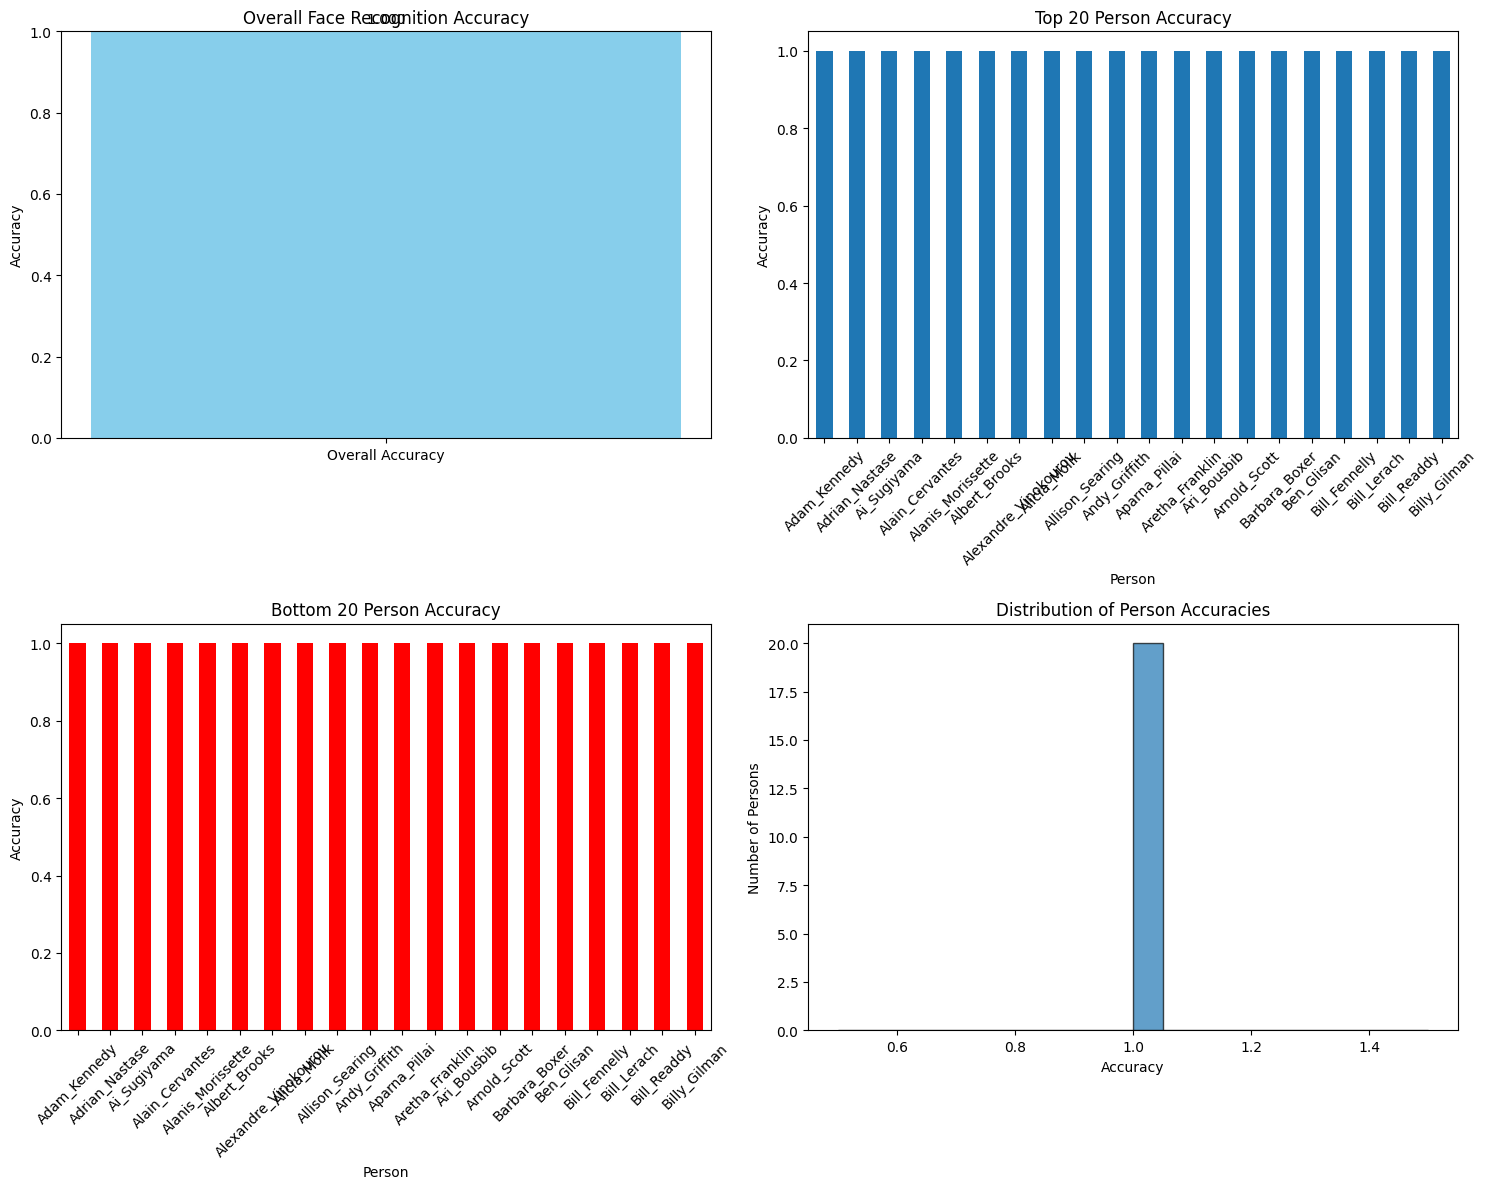

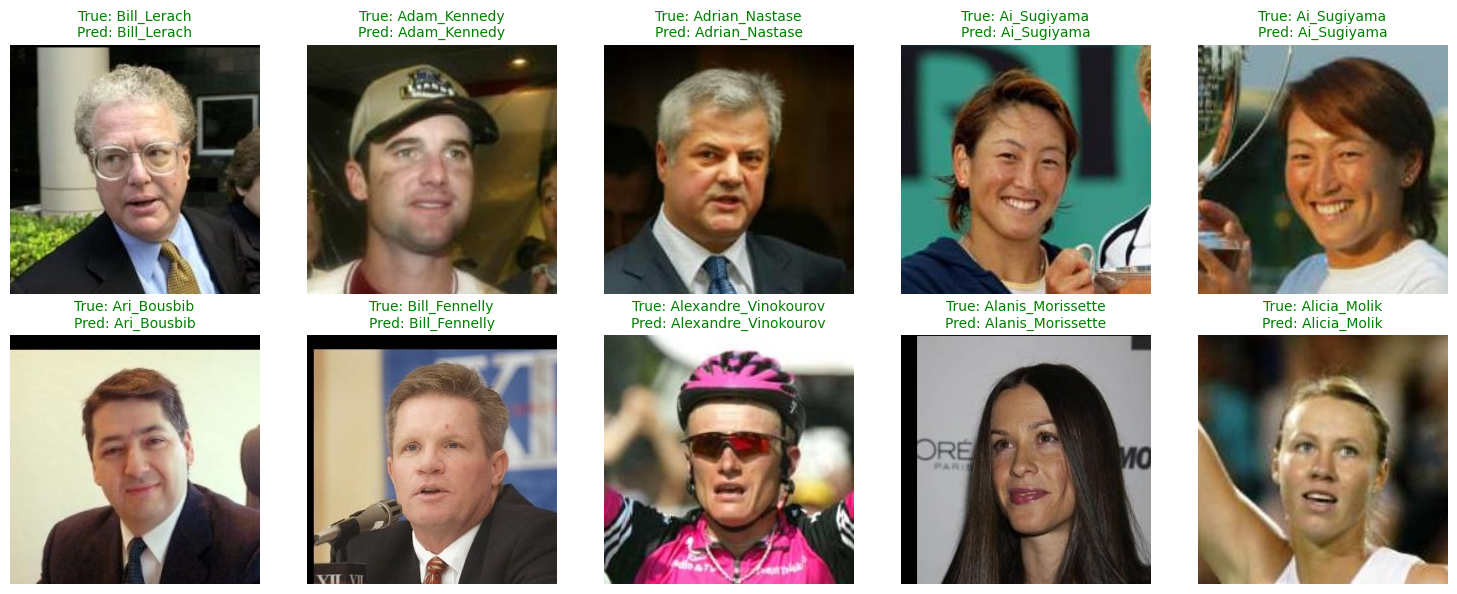


Results saved to:
- 'face_recognition_results.csv' (individual predictions)
- 'person_performance_stats.csv' (per-person statistics)

Face recognition evaluation completed!
Check the saved plots and CSV files for detailed results.


In [7]:
Test()